# Layer 1 -- Data Retrieval
- pull required economic indicators for a given model, such as "model_1.0", based on information in core_mappings.json
- validate the format and content of core_mappings.json
- stores in preliminary DataFrame

In [1]:
import json
import requests
import pandas as pd
import io

with open("core_mappings.json", "r") as config_file:
    config = json.load(config_file)

required_sections = [
    "indicators",
    "sources",
    "source_mappings",
    "model_definitions"
]

# Define the individual condition that make up structure_check
model_name = "model_1.0"
top_level_structure_valid = (
    all(section in config for section in required_sections)
    and all(isinstance(config[section], dict) for section in required_sections)
)

indicators_valid = (
    all(
        isinstance(name, str) and name.strip() != ""
        for name in config["indicators"]
    )
    and all(
        isinstance(indicator, list)
        and len(indicator) >= 2
        and isinstance(indicator[0], str)
        and indicator[0].strip() != ""
        and isinstance(indicator[1], str)
        and indicator[1].strip() != ""
        for indicator in config["indicators"].values()
    )
    and len(config["indicators"].values()) == len(set(
        indicator[0] for indicator in config["indicators"].values()
    ))
)

model_definitions_valid = (
    model_name in config["model_definitions"]
    and isinstance(config["model_definitions"][model_name], list)
    and all(
        indicator in [definition[0] for definition in config["indicators"].values()]
        for indicator in config["model_definitions"][model_name]
    )
)

sources_valid = (
        all(
        indicator in config["sources"]
        for indicator in config["model_definitions"][model_name]
    )
    and all(
            isinstance(config["sources"][indicator], list)
            for indicator in config["model_definitions"][model_name]
    )
    and all(
        len(config["sources"][indicator]) > 0
        for indicator in config["model_definitions"][model_name]
    )
)

source_mappings_valid = (
    all(
        source in config["source_mappings"]
        for indicator in config["model_definitions"][model_name]
        for source in config["sources"][indicator]
    )
    and all(
        indicator in config["source_mappings"][source]
        for indicator in config["model_definitions"][model_name]
        for source in config["sources"][indicator]
    )
    and all(
        isinstance(config["source_mappings"][source][indicator], list)
        and len(config["source_mappings"][source][indicator]) >= 2
        and isinstance(config["source_mappings"][source][indicator][-1], str)
        and config["source_mappings"][source][indicator][-1].strip() != ""
        for indicator in config["model_definitions"][model_name]
        for source in config["sources"][indicator]
    )
)

validation_checks = {
    "top_level_structure": top_level_structure_valid,
    "model_definitions": model_definitions_valid,
    "indicators": indicators_valid,
    "sources": sources_valid,
    "source_mappings": source_mappings_valid
}
failed_checks = [
    name for name, valid in validation_checks.items()
    if not valid
]

if failed_checks:
    raise ValueError(f"Configuration validation failed: {', '.join(failed_checks)}")

model_indicators = config["model_definitions"][model_name]

# ECB Data Retrieval Function
def retrieve_ecb_data(indicator):
    dataflow, series_key, source_unit = (
        config["source_mappings"]["ECB_API"][indicator]
    )

    canonical_unit = next(
        definition[1]
        for definition in config["indicators"].values()
        if definition[0] == indicator
    )

    url = (
        f"https://data-api.ecb.europa.eu/service/data/"
        f"{dataflow}/{series_key}?format=jsondata"
    )

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        data = response.json()

        series = next(iter(data["dataSets"][0]["series"].values()))

        time_periods = data["structure"]["dimensions"]["observation"][0]["values"]
        observations = series["observations"]

        rows = []

        for index, observation in observations.items():
            rows.append({
                "Time": time_periods[int(index)]["id"],
                "Indicator": indicator,
                "Value": observation[0],
                "Source_Unit": source_unit,
                "Canonical_Unit": canonical_unit,
                "Source": "ECB_API"
            })

        return True, pd.DataFrame(rows)

    except Exception as e:
        print(f"ECB_API failed for {indicator}: {e}")
        return False, None

# Offline Retrieval Function
# Offline Retrieval Function
def retrieve_offline_data(indicator):
    file_name, column_name, source_unit = (
        config["source_mappings"]["OFFLINE"][indicator]
    )

    canonical_unit = next(
        definition[1]
        for definition in config["indicators"].values()
        if definition[0] == indicator
    )

    try:
        if file_name.lower().endswith(".csv"):
            data = pd.read_csv(file_name)

        elif file_name.lower().endswith(".xlsx"):
            data = pd.read_excel(file_name)

        else:
            return False, None

        time_column = next(
            (
                column
                for column in data.columns
                if column.lower() in ["time", "date"]
            ),
            None
        )

        if time_column is None:
            return False, None

        data = data.rename(columns={time_column: "Time"})

        if column_name not in data.columns:
            return False, None

        data = data[data["Time"].notna()].copy()

        data = data[["Time", column_name]]

        data = data.rename(columns={column_name: "Value"})

        data.insert(1, "Indicator", indicator)
        data["Source_Unit"] = source_unit
        data["Canonical_Unit"] = canonical_unit
        data["Source"] = "OFFLINE"

        return True, data

    except Exception as e:
        print(e)
        return False, None

# JK Shock GitHub Retrieval Function
# GitHub JK Monetary Policy Shock Retrieval Function
def retrieve_JKshock_Github(indicator):

    owner, repository, file_name, column_name, source_unit = (
        config["source_mappings"]["GITHUB_JK"][indicator]
    )

    canonical_unit = next(
        definition[1]
        for definition in config["indicators"].values()
        if definition[0] == indicator
    )

    try:

        # Retrieve all repository branches
        branches_url = (
            f"https://api.github.com/repos/"
            f"{owner}/{repository}/branches"
        )

        response = requests.get(
            branches_url,
            params={"per_page": 100},
            timeout=30
        )

        response.raise_for_status()

        branches = response.json()

        if not branches:
            return False, None

        # Search every branch for the requested file
        file_data = None
        matched_branch = None

        for branch in branches:

            branch_name = branch["name"]

            file_url = (
                f"https://api.github.com/repos/"
                f"{owner}/{repository}/contents/"
                f"{file_name}"
            )

            response = requests.get(
                file_url,
                params={"ref": branch_name},
                timeout=30
            )

            if response.status_code == 200:

                file_data = response.json()
                matched_branch = branch_name
                break

            elif response.status_code != 404:

                response.raise_for_status()

        if file_data is None:
            print(
                f"GITHUB_JK failed for {indicator}: "
                f"File '{file_name}' not found in any branch."
            )
            return False, None

        # Retrieve raw file contents
        download_url = file_data.get("download_url")

        if download_url is None:
            return False, None

        response = requests.get(
            download_url,
            params={"ref": matched_branch},
            timeout=30
        )

        response.raise_for_status()

        data = pd.read_csv(
            io.StringIO(response.text)
        )

        # Validate required columns
        if "date" not in data.columns:
            return False, None

        if column_name not in data.columns:
            return False, None

        # Keep relevant observations
        data = data[
            data["date"].notna()
        ].copy()

        data = data[
            ["date", column_name]
        ]

        # Match Layer 1 output structure
        data = data.rename(
            columns={
                "date": "Time",
                column_name: "Value"
            }
        )

        data.insert(
            1,
            "Indicator",
            indicator
        )

        data["Source_Unit"] = source_unit
        data["Canonical_Unit"] = canonical_unit
        data["Source"] = "GITHUB_JK"

        return True, data

    except Exception as e:

        print(
            f"GITHUB_JK failed for {indicator}: {e}"
        )

        return False, None

# implement
working_data = []

retrieval_report = []

for indicator in model_indicators:
    indicator_retrieved = False

    for source in config["sources"][indicator]:

        if source == "ECB_API":
            success, data = retrieve_ecb_data(indicator)

        elif source == "OFFLINE":
            success, data = retrieve_offline_data(indicator)

        elif source == "GITHUB_JK":
            success, data = retrieve_JKshock_Github(indicator)

        else:
            success, data = False, None

        if success:
            working_data.append(data)

            retrieval_report.append({
                "Indicator": indicator,
                "Source": source,
                "Status": "Retrieved"
            })

            indicator_retrieved = True
            break

    if not indicator_retrieved:
        retrieval_report.append({
            "Indicator": indicator,
            "Source": None,
            "Status": "Unavailable"
        })

if working_data:
    working_df = pd.concat(working_data, ignore_index=True)
else:
    working_df = pd.DataFrame(
        columns=[
            "Time",
            "Indicator",
            "Value",
            "Source_Unit",
            "Canonical_Unit",
            "Source"
        ]
    )

retrieval_report = pd.DataFrame(retrieval_report)

# Layer 2 -- Data Preparation and Harmonization
- validate preliminary DataFrame from Layer 1 has expected format
- streamline "time" column to a yyyy-mm-dd format, according to indicator specific release lags

In [2]:
# Validate working_df structure
required_columns = ["Time", "Indicator", "Value", "Source_Unit", "Canonical_Unit",
                    "Source"]
missing_columns = [
    col for col in required_columns
    if col not in working_df.columns
                   ]
if missing_columns:
    raise ValueError(
        f"Layer 2 Validation failed. Missing columns: {', '.join(missing_columns)}"
        )

invalid_columns = []

if not working_df["Time"].apply(
    lambda x: isinstance(x, str) and x.strip() != ""
).all():
    invalid_columns.append("Time")

if not working_df["Indicator"].apply(
    lambda x: isinstance(x, str) and x.strip() != ""
).all():
    invalid_columns.append("Indicator")

missing_values = {None, "", " ", "None", "Missing"}

invalid_values = (
    ~working_df["Value"].isin(missing_values)
    & working_df["Value"].notna()
    & pd.to_numeric(
        working_df["Value"], errors="coerce"
    ).isna()
)

if invalid_values.any():
    invalid_columns.append("Value")

for column in ["Source_Unit", "Canonical_Unit", "Source"]:
    if not working_df[column].apply(
        lambda x: isinstance(x, str) and x.strip() != ""
    ).all():
        invalid_columns.append(column)

if invalid_columns:
    raise ValueError(
        f"Layer 2 Validation failed. Invalid data in columns: "
        f"{', '.join(invalid_columns)}"
    )

duplicate_index = ["Time", "Indicator"]

duplicate_groups = (
    working_df
    .groupby(duplicate_index)["Value"]
    .agg(["size", "nunique"])
)


exact_duplicates = duplicate_groups[
    duplicate_groups["nunique"] == 1
]

conflicting_duplicates = duplicate_groups[
    duplicate_groups["nunique"] > 1
]

if not exact_duplicates.empty:
    working_df = working_df.drop_duplicates(
        subset=["Time", "Indicator", "Value"],
        keep="first"
    )

if not conflicting_duplicates.empty:
    conflicting_index = conflicting_duplicates.index

    working_df = working_df.merge(
        conflicting_index.to_frame(index=False).assign(
            _conflicting_duplicate=True
        ),
        on=["Time", "Indicator"],
        how="left"
    )

    conflicting_count = (
        working_df["_conflicting_duplicate"]
        .fillna(False)
        .sum()
    )

    working_df = working_df[
        ~working_df["_conflicting_duplicate"].fillna(False)
    ].drop(columns="_conflicting_duplicate")

    print(
        f"Warning: {conflicting_count} observations removed because "
        f"duplicate Time + Indicator combinations contained different Values."
    )

import re

invalid_time_values = []

for value in working_df["Time"]:
    if not isinstance(value, str):
        invalid_time_values.append(value)
        continue

    time_value = value.strip().upper()

    if (
        re.fullmatch(r"\d{4}", time_value)
        or re.fullmatch(r"\d{4}-Q[1-4]", time_value)
        or re.fullmatch(r"\d{4}-\d{2}", time_value)
        or re.fullmatch(r"\d{4}-\d{2}-\d{2}", time_value)
        or re.fullmatch(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}", time_value)
    ):
        continue

    invalid_time_values.append(value)

if invalid_time_values:
    raise ValueError(
        f"Layer 2 Validation failed. Invalid Time format(s): "
        f"{', '.join(map(str, invalid_time_values))}"
    )

# streamline temporal column
release_lag_rules = {
    30: ["EURIBOR_3M"],
    45: ["HICP", "HICPX_SUPPLY", "HICPX_DEMAND"],
    60: [],
    120: []
}

def streamline_dates_fixed_lag(df, release_lag_rules):
    df = df.copy()

    lag_lookup = {
        indicator: lag
        for lag, indicators in release_lag_rules.items()
        for indicator in indicators
    }

    def transform_date(value, indicator):
        if isinstance(value, pd.Timestamp):
            return value.normalize()

        if not isinstance(value, str):
            value = pd.Timestamp(value)
            return value.normalize()

        value = value.strip()

        if re.fullmatch(r"\d{4}-Q[1-4]", value, re.IGNORECASE):
            year = int(value[:4])
            quarter = int(value[-1])
            month = (quarter - 1) * 3 + 1
            date = pd.Timestamp(year=year, month=month, day=1)

            if indicator not in lag_lookup:
                raise ValueError(
                    f"No release lag defined for non-daily indicator: {indicator}"
                )

            return date + pd.Timedelta(days=lag_lookup[indicator])

        if re.fullmatch(r"\d{4}-\d{2}", value):
            date = pd.to_datetime(value, format="%Y-%m")

            if indicator not in lag_lookup:
                raise ValueError(
                    f"No release lag defined for non-daily indicator: {indicator}"
                )

            return date + pd.Timedelta(days=lag_lookup[indicator])

        if re.fullmatch(r"\d{4}", value):
            date = pd.to_datetime(value, format="%Y")

            if indicator not in lag_lookup:
                raise ValueError(
                    f"No release lag defined for non-daily indicator: {indicator}"
                )

            return date + pd.Timedelta(days=lag_lookup[indicator])

        if re.fullmatch(r"\d{4}-\d{2}-\d{2}", value):
            return pd.to_datetime(value, format="%Y-%m-%d")

        if re.fullmatch(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}", value):
            return pd.to_datetime(value).normalize()

        raise ValueError(
            f"Unrecognized Time format: {value}"
        )

    df["Time"] = [
        transform_date(time, indicator)
        for time, indicator in zip(df["Time"], df["Indicator"])
    ]

    df = df.rename(columns={"Time": "Date"})

    expanded_data = []

    for indicator, group in df.groupby("Indicator"):
        date_range = pd.date_range(
        start=min(group["Date"]),
        end=max(group["Date"]),
        freq="D"
    )

        group = (
        group
        .set_index("Date")
        .reindex(date_range)
        .rename_axis("Date")
        .reset_index()
    )

        group["Indicator"] = indicator

        for column in ["Source_Unit", "Canonical_Unit", "Source"]:
            group[column] = group[column].ffill().bfill()

        expanded_data.append(group)

    df = pd.concat(expanded_data, ignore_index=True)
    df["Date"] = df["Date"].dt.date

    return df

working_df = streamline_dates_fixed_lag(
    working_df,
    release_lag_rules
)

model_df = (
    working_df
    .pivot(index="Date", columns="Indicator", values="Value")
    .reset_index()
)

model_df.columns.name = None
model_df

,Date,AAA_1Y,HICPX_DEMAND,HICPX_SUPPLY,MP_SHOCK
0,1999-01-07,NaN,NaN,NaN,0.020578
1,1999-01-08,NaN,NaN,NaN,NaN
2,1999-01-09,NaN,NaN,NaN,NaN
3,1999-01-10,NaN,NaN,NaN,NaN
4,1999-01-11,NaN,NaN,NaN,NaN
...,...,...,...,...,...
10117,2026-09-19,NaN,NaN,NaN,NaN
10118,2026-09-20,NaN,NaN,NaN,NaN
10119,2026-09-21,2.976898,NaN,NaN,NaN
10120,2026-09-22,2.967921,NaN,NaN,NaN


# Layer 3 -- Model Construction
- computes linear (OLS) model for available data, may include imputations such as Last Observation Carried Forward (LOCF)

In [3]:
import statsmodels.formula.api as smf

# extract ECB meeting dates
df_meetings = pd.read_csv(
        "provisional_dataset.csv", 
        usecols=["Time", "Event"])
ecb_meetings = (
        df_meetings
        .loc[df_meetings["Event"].notna(), "Time"])

def model_01(df, time_span):

    # restrict time span
    df = df[
        (df["Date"] >= pd.to_datetime(time_span[0]).date())
        & (df["Date"] <= pd.to_datetime(time_span[1]).date())
    ]

    # create model-specific aggregate columns
    df["AAA_1Y_change"] = df["AAA_1Y"].diff()

    numeric_columns = df.select_dtypes(include="number").columns

    df[numeric_columns] = (
    df[numeric_columns]
    .ffill()
    )

    event_ois_changes = {}

    for meeting_date in ecb_meetings:

        meeting_date = pd.to_datetime(meeting_date).date()

        before_candidates = df[
        (df["Date"] < meeting_date)
        & (df["Date"] >= meeting_date - pd.Timedelta(days=3))
        ]

        after_candidates = df[
        (df["Date"] > meeting_date)
        & (df["Date"] <= meeting_date + pd.Timedelta(days=3))
        ]

        if before_candidates.empty or after_candidates.empty:
            continue

        before_value = before_candidates.iloc[0]["OIS_1M"]
        after_value = after_candidates.iloc[-1]["OIS_1M"]

        event_ois_changes[meeting_date] = after_value - before_value

    ois_threshold = pd.Series(event_ois_changes).quantile(0.75)

    df["MPS"] = 0

    for meeting_date, event_change in event_ois_changes.items():

        if event_change >= ois_threshold:
            df.loc[df["Date"] == meeting_date, "MPS"] = 1

    model = smf.ols(
    "AAA_1Y_change ~ MPS * HICPX_DEMAND + MPS * HICPX_SUPPLY",
    data=df
    ).fit()

    print(model.summary())
    return model, df

def model_10(df, time_span):

    df = df[
        (df["Date"] >= pd.to_datetime(time_span[0]).date())
        & (df["Date"] <= pd.to_datetime(time_span[1]).date())
    ].copy()

    df["AAA_1Y_change"] = df["AAA_1Y"].diff()

    # Calculate the shock threshold using actual MP_SHOCK observations
    mp_threshold = df["MP_SHOCK"].dropna().quantile(0.75)

    # Label only actual shock observations
    df["MPT"] = (
        df["MP_SHOCK"].notna()
        & (df["MP_SHOCK"] >= mp_threshold)
    ).astype(int)

    # Forward-fill the other numeric variables
    numeric_columns = df.select_dtypes(include="number").columns
    numeric_columns = numeric_columns.drop(
        ["MP_SHOCK", "MPT"],
        errors="ignore"
    )

    df[numeric_columns] = (
        df[numeric_columns]
        .ffill()
    )

    model = smf.ols(
        "AAA_1Y_change ~ MPT * HICPX_DEMAND + MPT * HICPX_SUPPLY",
        data=df
    ).fit()

    print(model.summary())

    return model, df


if model_name == 'layer1_test_selection':
    raise ValueError("You have selected an invalid model. Please select another model.")
elif model_name == 'model_0.1':

    time_span = ("2017-02-15", "2022-10-16")

    # Check required columns
    required_columns = ["Date"] + model_indicators

    missing_columns = [
        column
        for column in required_columns
        if column not in model_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Model 0.1 validation failed. Missing columns: "
            f"{', '.join(missing_columns)}"
        )

    # Check for duplicate dates
    if model_df["Date"].duplicated().any():
        raise ValueError(
            "Model 0.1 validation failed. Duplicate dates found in model_df."
        )

    # Check complete calendar range
    expected_dates = pd.date_range(
        start=time_span[0],
        end=time_span[1],
        freq="D"
    )

    actual_dates = pd.to_datetime(model_df["Date"])

    missing_dates = expected_dates.difference(actual_dates)

    if not missing_dates.empty:
        raise ValueError(
            f"Model 0.1 validation failed. "
            f"{len(missing_dates)} calendar dates are missing "
            f"within the selected time span."
        )

    # Check that no required indicator is entirely missing
    empty_indicators = [
        indicator
        for indicator in model_indicators
        if model_df[indicator].isna().all()
    ]

    if empty_indicators:
        raise ValueError(
            f"Model 0.1 validation failed. No usable observations found "
            f"for: {', '.join(empty_indicators)}"
        )

    model_result, model_df = model_01(model_df, time_span)
    model_result
elif model_name == 'model_1.0':

    time_span = ("2017-02-15", "2022-10-16")

    # Check required columns
    required_columns = ["Date"] + model_indicators

    missing_columns = [
        column
        for column in required_columns
        if column not in model_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Model 1.0 validation failed. Missing columns: "
            f"{', '.join(missing_columns)}"
        )

    # Check for duplicate dates
    if model_df["Date"].duplicated().any():
        raise ValueError(
            "Model 1.0 validation failed. Duplicate dates found in model_df."
        )

    # Check complete calendar range
    expected_dates = pd.date_range(
        start=time_span[0],
        end=time_span[1],
        freq="D"
    )

    actual_dates = pd.to_datetime(model_df["Date"])

    missing_dates = expected_dates.difference(actual_dates)

    if not missing_dates.empty:
        raise ValueError(
            f"Model 1.0 validation failed. "
            f"{len(missing_dates)} calendar dates are missing "
            f"within the selected time span."
        )

    # Check that no required indicator is entirely missing
    empty_indicators = [
        indicator
        for indicator in model_indicators
        if model_df[indicator].isna().all()
    ]

    if empty_indicators:
        raise ValueError(
            f"Model 1.0 validation failed. No usable observations found "
            f"for: {', '.join(empty_indicators)}"
        )

    model_result, model_df = model_10(model_df, time_span)
    model_result

                            OLS Regression Results                            
Dep. Variable:          AAA_1Y_change   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     30.06
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.42e-29
Time:                        21:56:36   Log-Likelihood:                 5017.7
No. Observations:                2069   AIC:                        -1.002e+04
Df Residuals:                    2063   BIC:                            -9990.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0056      0.001  

# Layer 4 -- Results and Visualization
- visualizes model results from the previous Layer

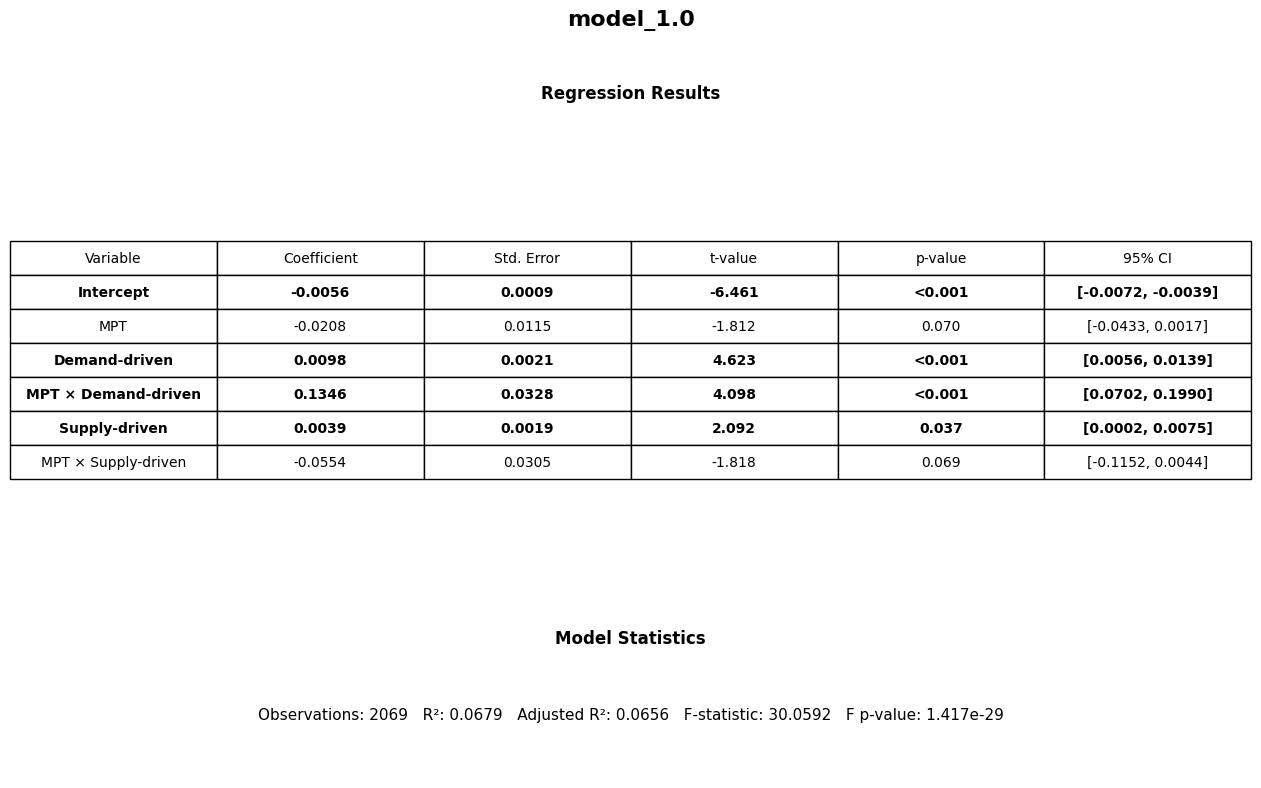

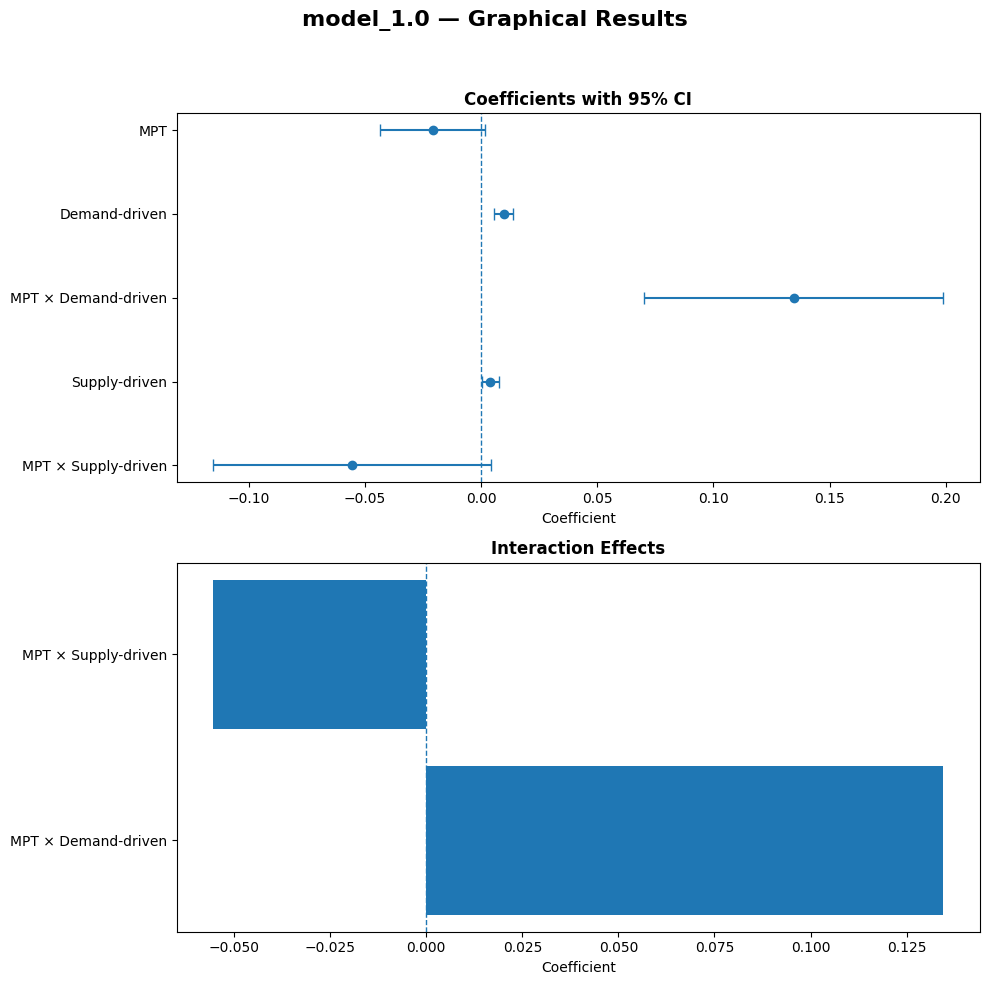

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

indicator_names = {
    internal_name: real_name
    for real_name, (internal_name, unit) in config["indicators"].items()
}

indicator_names["HICPX_DEMAND"] = "Demand-driven"
indicator_names["HICPX_SUPPLY"] = "Supply-driven"

def output_plot(
    model,
    model_name,
    indicators,
    interactions=None,
    table_statistics=None,
    model_statistics=None
):
    def display_name(term):
        parts = term.split(":")
        return " × ".join(
            indicator_names.get(part, part)
            for part in parts
        )

    interactions = interactions or []

    table_statistics = table_statistics or [
        "coef",
        "std_err",
        "t_value",
        "p_value",
        "conf_int"
    ]

    model_statistics = model_statistics or [
        "nobs",
        "rsquared",
        "rsquared_adj",
        "fvalue",
        "f_pvalue"
    ]

    params = model.params
    conf_int = model.conf_int()
    pvalues = model.pvalues

    # 1. Regression results table

    statistic_labels = {
        "coef": "Coefficient",
        "std_err": "Std. Error",
        "t_value": "t-value",
        "p_value": "p-value",
        "conf_int": "95% CI"
    }

    table_data = []

    for term in params.index:

        row = [display_name(term)]

        for statistic in table_statistics:

            if statistic == "coef":
                row.append(f"{params[term]:.4f}")

            elif statistic == "std_err":
                row.append(f"{model.bse[term]:.4f}")

            elif statistic == "t_value":
                row.append(f"{model.tvalues[term]:.3f}")

            elif statistic == "p_value":
                if pvalues[term] < 0.001:
                    row.append("<0.001")
                else:
                    row.append(f"{pvalues[term]:.3f}")

            elif statistic == "conf_int":
                row.append(
                    f"[{conf_int.loc[term, 0]:.4f}, "
                    f"{conf_int.loc[term, 1]:.4f}]"
                )

        table_data.append(row)

    column_labels = (
        ["Variable"]
        + [statistic_labels[s] for s in table_statistics]
    )

    # 2. Coefficient + 95% CI plot

    plot_terms = [
        term
        for term in params.index
        if term.lower() not in ("intercept", "const")
    ]

    coefficients = np.array(
        [params[term] for term in plot_terms]
    )

    lower = np.array(
        [conf_int.loc[term, 0] for term in plot_terms]
    )

    upper = np.array(
        [conf_int.loc[term, 1] for term in plot_terms]
    )

    errors = np.array([
        coefficients - lower,
        upper - coefficients
    ])

    # 3. Interaction-effect plot

    interaction_labels = []
    interaction_coefficients = []

    for interaction in interactions:

        interaction_term = ":".join(interaction)

        if interaction_term in params.index:
            interaction_labels.append(
                display_name(f"{interaction[0]}:{interaction[1]}")
            )
            interaction_coefficients.append(
                params[interaction_term]
            )

    # 4. Model statistics

    statistic_values = {}

    for statistic in model_statistics:

        if statistic == "nobs":
            statistic_values["Observations"] = int(model.nobs)

        elif statistic == "rsquared":
            statistic_values["R²"] = f"{model.rsquared:.4f}"

        elif statistic == "rsquared_adj":
            statistic_values["Adjusted R²"] = (
                f"{model.rsquared_adj:.4f}"
            )

        elif statistic == "fvalue":
            statistic_values["F-statistic"] = (
                f"{model.fvalue:.4f}"
            )

        elif statistic == "f_pvalue":
            statistic_values["F p-value"] = (
                f"{model.f_pvalue:.4g}"
            )

    statistics_text = "   ".join(
        f"{name}: {value}"
        for name, value in statistic_values.items()
    )

    # Figure 1: Regression table + model statistics

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        gridspec_kw={"height_ratios": [4, 1]}
    )

    # Regression table

    axes[0].axis("off")

    table = axes[0].table(
        cellText=table_data,
        colLabels=column_labels,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.5, 1.8)

    axes[0].set_title(
        "Regression Results",
        fontweight="bold"
    )

    # Highlight significant coefficients

    for row_index, term in enumerate(params.index, start=1):

        if pvalues[term] < 0.05:

            for column_index in range(len(column_labels)):
                table[
                    row_index,
                    column_index
                ].set_text_props(fontweight="bold")

    # Model statistics

    axes[1].axis("off")

    axes[1].text(
        0.5,
        0.5,
        statistics_text,
        ha="center",
        va="center",
        fontsize=11
    )

    axes[1].set_title(
        "Model Statistics",
        fontweight="bold"
    )

    fig.suptitle(
        f"{model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()

    # Figure 2: Graphical results

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 10)
    )

    # Coefficient plot

    y_positions = np.arange(len(plot_terms))

    axes[0].errorbar(
        coefficients,
        y_positions,
        xerr=errors,
        fmt="o",
        capsize=4
    )

    axes[0].axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    axes[0].set_yticks(y_positions)

    axes[0].set_yticklabels(
        [display_name(term) for term in plot_terms]
    )

    axes[0].invert_yaxis()

    axes[0].set_xlabel("Coefficient")

    axes[0].set_title(
        "Coefficients with 95% CI",
        fontweight="bold"
    )

    # Interaction plot

    if interaction_coefficients:

        axes[1].barh(
            interaction_labels,
            interaction_coefficients
        )

        axes[1].axvline(
            0,
            linestyle="--",
            linewidth=1
        )

        axes[1].set_xlabel("Coefficient")

        axes[1].set_title(
            "Interaction Effects",
            fontweight="bold"
        )

    else:

        axes[1].text(
            0.5,
            0.5,
            "No interaction terms specified",
            ha="center",
            va="center"
        )

        axes[1].axis("off")

    fig.suptitle(
        f"{model_name} — Graphical Results",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()


if model_name == "model_0.1":

    if not hasattr(model_result, "params"):
        raise ValueError(
            "Layer 4 validation failed. Model result is not a valid "
            "statsmodels regression result."
        )

    output_plot(
        model=model_result,
        model_name=model_name,
        indicators=model_indicators,
        interactions=[
            ("MPS", "HICPX_DEMAND"),
            ("MPS", "HICPX_SUPPLY")
        ],
        table_statistics=[
            "coef",
            "std_err",
            "t_value",
            "p_value",
            "conf_int"
        ],
        model_statistics=[
            "nobs",
            "rsquared",
            "rsquared_adj",
            "fvalue",
            "f_pvalue"
        ]
    )
elif model_name == "model_1.0":

    if not hasattr(model_result, "params"):
        raise ValueError(
            "Layer 4 validation failed. Model result is not a valid "
            "statsmodels regression result."
        )

    output_plot(
        model=model_result,
        model_name=model_name,
        indicators=model_indicators,
        interactions=[
            ("MPT", "HICPX_DEMAND"),
            ("MPT", "HICPX_SUPPLY")
        ],
        table_statistics=[
            "coef",
            "std_err",
            "t_value",
            "p_value",
            "conf_int"
        ],
        model_statistics=[
            "nobs",
            "rsquared",
            "rsquared_adj",
            "fvalue",
            "f_pvalue"
        ]
    )

# 